# 1. Check the input data

The pipeline starts from two third-party datasets that this repository does not
redistribute: the MESSENGER/MDIS global mosaic and the MASCS/VIRS point spectra
curated by O. Barraud. Step 1 alone reads about 35 GB and runs for hours, so it is
worth spending one minute first making sure the files on disk are the ones the
project was built on.

This notebook answers four questions:

1. are the expected files there, and is the MDIS mosaic on the grid the code assumes?
2. are its 17 bands the ones the model expects (8 reflectances, 1 image-set count, 8 standard deviations)?
3. do the MASCS quality flags select the same population of spectra as in the reference run?
4. if steps 1-2 have already run, are the derived tables self-consistent, and is the
   split free of spatial leakage?

Nothing here writes anything, and nothing raises: a missing file becomes a line in the
final table. See [docs/DATA.md](../docs/DATA.md) for provenance and the expected layout.

In [1]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

RAW = REPO / "data/raw"
MDIS = RAW / "mdis_mosaic/MDIS_MDR_20170512_PDS16_64ppd_equirectangular_withbackplanes.tif"
MASCS = RAW / "mascs"
SPECTRA = MASCS / "Spectra_0_360_-90_90_spectres-002.dat"
QUALITY = MASCS / "Spectra_0_360_-90_90_quality.dat"
GEOMETRY = MASCS / "Spectra_0_360_-90_90_geometry.dat"
SHAPES = MASCS / "Spectra_0_360_-90_90_shapes.dat"
MDISDATA = MASCS / "Spectra_0_360_-90_90_MDISdata.dat"
PROC = REPO / "data/processed"

NODATA = -1e30          # anything at or below this is a nodata value
CHECKS = []


def check(name, ok, detail=""):
    CHECKS.append({"check": name, "result": "PASS" if ok else "FAIL", "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}]  {name}" + (f"    {detail}" if detail else ""))
    return bool(ok)


# Some IDEs inject their own (often dark) matplotlib theme into the kernel, which
# would render this notebook's figures with white text on a white background.
# Reset to the matplotlib defaults so the figures look the same for everyone.
plt.style.use("default")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "savefig.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"repository '{REPO.name}' | numpy {np.__version__} | pandas {pd.__version__} "
      f"| rasterio {rasterio.__version__}")

repository 'mdis2vihi' | numpy 2.4.4 | pandas 3.0.3 | rasterio 1.4.4


## 1. Are the files there?

In [2]:
EXPECTED = [(MDIS, "MDIS global mosaic, 17 bands", "required"),
            (SPECTRA, "MASCS/VIRS spectra", "required"),
            (QUALITY, "MASCS quality flags q1..q4", "required"),
            (GEOMETRY, "MASCS footprint geometry", "required"),
            (SHAPES, "MASCS footprint polygons (WKT)", "required"),
            (MDISDATA, "terrain indicators", "step 5 only")]

rows = []
for path, what, role in EXPECTED:
    here = path.exists()
    rows.append({"file": path.relative_to(REPO).as_posix(), "content": what, "role": role,
                 "GB": round(path.stat().st_size / 1e9, 2) if here else None,
                 "state": "present" if here else "MISSING"})
inventory = pd.DataFrame(rows)

check("every required input file is present",
      all(r["state"] == "present" for r in rows if r["role"] == "required"),
      f"{sum(r['state'] == 'present' for r in rows)}/{len(rows)} files found")
inventory

[PASS]  every required input file is present    6/6 files found


,file,content,role,GB,state
0,data/raw/mdis_mosaic/MDIS_MDR_20170512_PDS16_6...,"MDIS global mosaic, 17 bands",required,18.05,present
1,data/raw/mascs/Spectra_0_360_-90_90_spectres-0...,MASCS/VIRS spectra,required,31.12,present
2,data/raw/mascs/Spectra_0_360_-90_90_quality.dat,MASCS quality flags q1..q4,required,0.34,present
3,data/raw/mascs/Spectra_0_360_-90_90_geometry.dat,MASCS footprint geometry,required,0.59,present
4,data/raw/mascs/Spectra_0_360_-90_90_shapes.dat,MASCS footprint polygons (WKT),required,1.51,present
5,data/raw/mascs/Spectra_0_360_-90_90_MDISdata.dat,terrain indicators,step 5 only,0.20,present


## 2. Is the MDIS mosaic on the expected grid?

The deliverable inherits its georeferencing from this file, pixel for pixel, so any
difference here propagates all the way to the output mosaic. The expected values come
from the file the project was built on.

In [3]:
SPEC = {"width": 23040, "height": 11521, "count": 17, "dtype": "float32",
        "res_m": 665.24315270546, "radius_m": 2439400.0}

with rasterio.open(MDIS) as ds:
    prof = {"width": ds.width, "height": ds.height, "count": ds.count,
            "dtype": ds.dtypes[0], "nodata": ds.nodata, "res_m": ds.transform.a,
            "block_shape": ds.block_shapes[0],
            "bounds_x_m": (round(ds.bounds.left, 1), round(ds.bounds.right, 1)),
            "bounds_y_m": (round(ds.bounds.bottom, 1), round(ds.bounds.top, 1))}
    crs_wkt = ds.crs.to_wkt()

for key in ("width", "height", "count", "dtype"):
    check(f"MDIS {key} = {SPEC[key]}", prof[key] == SPEC[key], f"read {prof[key]}")
check("pixel size 665.24315270546 m (1/64 deg at the equator)",
      abs(prof["res_m"] - SPEC["res_m"]) < 1e-6, f"read {prof['res_m']:.9f} m")
check("CRS is equirectangular on a Mercury sphere of 2 439 400 m",
      "2439400" in crs_wkt and "Equirectangular" in crs_wkt, crs_wkt.split(",")[0])
check("nodata is the large negative nodata value", prof["nodata"] < NODATA,
      f"{prof['nodata']:.6e}")
pd.Series(prof).to_frame("value")

[PASS]  MDIS width = 23040    read 23040
[PASS]  MDIS height = 11521    read 11521
[PASS]  MDIS count = 17    read 17
[PASS]  MDIS dtype = float32    read float32
[PASS]  pixel size 665.24315270546 m (1/64 deg at the equator)    read 665.243152705 m
[PASS]  CRS is equirectangular on a Mercury sphere of 2 439 400 m    PROJCS["Equirectangular Mercury"
[PASS]  nodata is the large negative nodata value    -3.402823e+38


,value
width,23040
height,11521
count,17
dtype,float32
nodata,-340282265508890445205022487695511781376.0
res_m,665.243153
block_shape,"(1, 23040)"
bounds_x_m,"(-7663601.1, 7663601.1)"
bounds_y_m,"(-3832465.8, 3831800.6)"


## 3. Are the 17 bands the ones the model expects?

| bands | content |
|---|---|
| 1-8 | the 8 MDIS/WAC I/F filters, ascending: 433, 480, 559, 629, 749, 828, 899, 996 nm |
| 9 | count of 8-colour image sets averaged into the pixel, an integer 0-86 |
| 10-17 | standard deviation of that average, one per I/F band, same order |


[PASS]  bands 1-8 rise with wavelength (Mercury's red slope)    median I/F 0.042 -> 0.085
[PASS]  band 9 is integer-valued (a count, not an angle)    81% of pixels exactly integer, 189,853 distinct values over 1,036,800 pixels, range -0.45 to 86.0
[PASS]  the standard deviation vanishes where band 9 = 1    exactly zero on 99.985% of 38,960 single-image pixels, residual max 2.6e-09 on the rest
[PASS]  the standard deviation falls as 1 / sqrt(count)    log-log slope -0.537 against -0.5 expected, on 914,878 pixels
[PASS]  bands 10-17 are the standard deviations (about 1 % of the I/F)    sigma / (I/F) from 0.60% to 0.81%


,band,lambda_nm,median_iof,sigma_band,median_sigma,sigma_over_iof
0,1,433,0.0422,10,0.000343,0.81%
1,2,480,0.0492,11,0.000391,0.79%
2,3,559,0.0568,12,0.000422,0.74%
3,4,629,0.0628,13,0.000508,0.81%
4,5,749,0.0704,14,0.000518,0.74%
5,6,828,0.0788,15,0.000499,0.63%
6,7,899,0.0822,16,0.000514,0.63%
7,8,996,0.0848,17,0.000511,0.60%


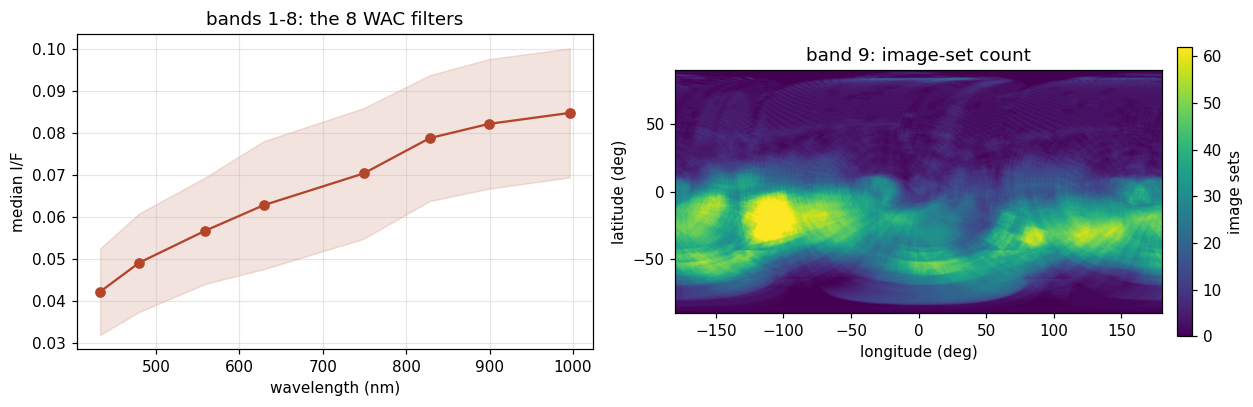

In [4]:
WAC_NM = np.array([433, 480, 559, 629, 749, 828, 899, 996])
DECIM = 16

with rasterio.open(MDIS) as ds:
    dec = ds.read(out_shape=(ds.count, ds.height // DECIM, ds.width // DECIM)).astype(np.float32)
dec[dec <= NODATA] = np.nan

med = np.nanmedian(dec.reshape(dec.shape[0], -1), axis=1)
iof, count, sigma = med[:8], dec[8], med[9:17]
rel = sigma / iof

check("bands 1-8 rise with wavelength (Mercury's red slope)",
      bool(np.all(np.diff(iof) > 0)), f"median I/F {iof[0]:.3f} -> {iof[-1]:.3f}")

# --- band 9 is a count of images ---------------------------------
c = count[np.isfinite(count)]
frac_int = float(np.mean(np.abs(c - np.round(c)) < 1e-6))
check("band 9 is integer-valued (a count, not an angle)", frac_int > 0.5,
      f"{frac_int:.0%} of pixels exactly integer, {np.unique(c).size:,} distinct values "
      f"over {c.size:,} pixels, range {c.min():.2f} to {c.max():.1f}")

# The count is the number of images averaged, so a pixel built from one image has a
# standard deviation of exactly zero, and sigma falls as 1/sqrt(count) beyond that.
s749 = dec[13]                                    # sigma of band 5 (749 nm) = band 14
one = np.isfinite(s749) & (np.abs(count - 1) < 1e-6)
exact = float(np.mean(s749[one] == 0.0))
check("the standard deviation vanishes where band 9 = 1", exact > 0.999,
      f"exactly zero on {exact:.3%} of {int(one.sum()):,} single-image pixels, "
      f"residual max {np.nanmax(np.abs(s749[one])):.1e} on the rest")

m = np.isfinite(s749) & (s749 > 0) & (count >= 2) & np.isfinite(dec[4]) & (dec[4] > 0)
p = np.polyfit(np.log(count[m]), np.log(s749[m] / dec[4][m]), 1)[0]
check("the standard deviation falls as 1 / sqrt(count)", -0.75 < p < -0.25,
      f"log-log slope {p:.3f} against -0.5 expected, on {int(m.sum()):,} pixels")

check("bands 10-17 are the standard deviations (about 1 % of the I/F)",
      bool(np.all((rel > 0.002) & (rel < 0.03))),
      f"sigma / (I/F) from {rel.min():.2%} to {rel.max():.2%}")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(WAC_NM, iof, "o-", color="#b3452a")
ax[0].fill_between(WAC_NM, iof - sigma * 30, iof + sigma * 30, color="#b3452a", alpha=0.15)
ax[0].set(xlabel="wavelength (nm)", ylabel="median I/F",
          title="bands 1-8: the 8 WAC filters")
im = ax[1].imshow(count, extent=[-180, 180, -90, 90], cmap="viridis",
                  vmin=0, vmax=float(np.nanpercentile(count, 99)))
ax[1].set(xlabel="longitude (deg)", ylabel="latitude (deg)",
          title="band 9: image-set count")
ax[1].grid(False)
fig.colorbar(im, ax=ax[1], fraction=0.028, pad=0.03, label="image sets")
fig.tight_layout()

pd.DataFrame({"band": np.arange(1, 9), "lambda_nm": WAC_NM, "median_iof": iof.round(4),
              "sigma_band": np.arange(10, 18), "median_sigma": sigma.round(6),
              "sigma_over_iof": [f"{r:.2%}" for r in rel]})

## 4. Do the quality flags select the same spectra?

`q1..q4` are Barraud's quality indicators, and the pipeline keeps
`q1` in [0.9, 1.1], `|q2| < 5`, `q3 > 80`, `q4 > 95`. This is the single most
consequential check in this notebook: the filter keeps under 5 % of the corpus, so a
different file, or different flags, means a different training set and every number
downstream moves.

`q1` (the VIS/NIR slope-ratio, target 1) dominates: it alone rejects about 91 % of
the corpus.

The bounds on `q1` are **inclusive**, as in `scripts/01_build_pairs.py`; testing them
strictly drops more spectra.

good set:                3,172,422 spectra   10,177 observations
  q1 alone:               286,832 (  9.0%)
  q2 alone:             3,152,148 ( 99.4%)
  q3 alone:             2,438,671 ( 76.9%)
  q4 alone:             1,974,217 ( 62.2%)
all four:                  154,064 spectra    5,629 observations
[PASS]  the good set holds about 3.17 M spectra    3,172,422
[PASS]  the quality filter keeps the reference 154 064 spectra    154,064
[PASS]  about 5 600 observations survive (the group key of the split)    5,629


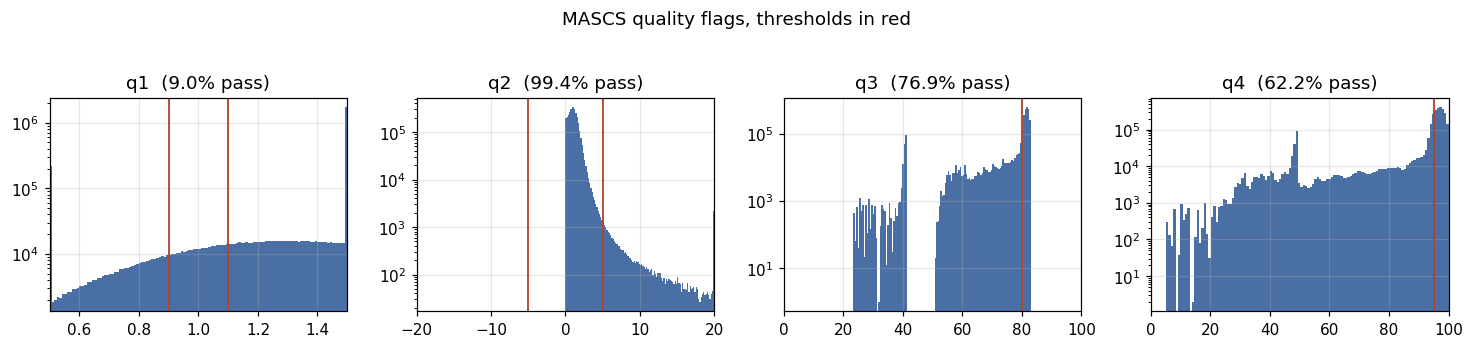

In [5]:
q = pd.read_csv(QUALITY, usecols=["ref_id", "q1", "q2", "q3", "q4", "obs_id"])
cuts = {"q1": q.q1.between(0.9, 1.1), "q2": q.q2.abs() < 5,
        "q3": q.q3 > 80, "q4": q.q4 > 95}
keep = cuts["q1"] & cuts["q2"] & cuts["q3"] & cuts["q4"]

print(f"good set:               {len(q):>10,} spectra   {q.obs_id.nunique():>6,} observations")
for name, m in cuts.items():
    print(f"  {name} alone:            {int(m.sum()):>10,} ({m.mean():6.1%})")
print(f"all four:               {int(keep.sum()):>10,} spectra   "
      f"{q.loc[keep, 'obs_id'].nunique():>6,} observations")

check("the good set holds about 3.17 M spectra", abs(len(q) - 3_172_422) < 50_000, f"{len(q):,}")
check("the quality filter keeps the reference 154 064 spectra",
      abs(int(keep.sum()) - 154_064) < 1_600, f"{int(keep.sum()):,}")
check("about 5 600 observations survive (the group key of the split)",
      abs(q.loc[keep, "obs_id"].nunique() - 5_629) < 200, f"{q.loc[keep, 'obs_id'].nunique():,}")

fig, ax = plt.subplots(1, 4, figsize=(13.5, 3.0))
for a, (name, rng, lo, hi) in zip(ax, [("q1", (0.5, 1.5), 0.9, 1.1),
                                       ("q2", (-20, 20), -5, 5),
                                       ("q3", (0, 100), 80, None),
                                       ("q4", (0, 100), 95, None)]):
    a.hist(q[name].clip(*rng), bins=120, color="#4a6fa5")
    for v in (lo, hi):
        if v is not None:
            a.axvline(v, color="#b3452a", lw=1.2)
    a.set(title=f"{name}  ({cuts[name].mean():.1%} pass)", yscale="log", xlim=rng)
fig.suptitle("MASCS quality flags, thresholds in red", y=1.04)
fig.tight_layout()

## 5. Are the spectra readable, and do they cover the target range?

The `.dat` sidecars are CSV despite the extension, and in `spectres-002.dat` the
`waves` and `photom_iof` columns are stringified Python lists: they need
`ast.literal_eval`, not a numeric parser. Spectra have a **variable** number of bins,
because Barraud's cleaning drops bad ones per spectrum, which is exactly why the
pipeline resamples everything onto a common 5 nm grid.

Only the first few thousand rows are read here; the file is about 30 GB.

[PASS]  spectres-002.dat has the expected columns    ref_id, id, waves, photom_iof, obs_id
[PASS]  spectra have a variable number of bins    341 to 525 bins, median 487
[PASS]  coverage spans the 300-1450 nm target grid    median coverage 264 to 1487 nm


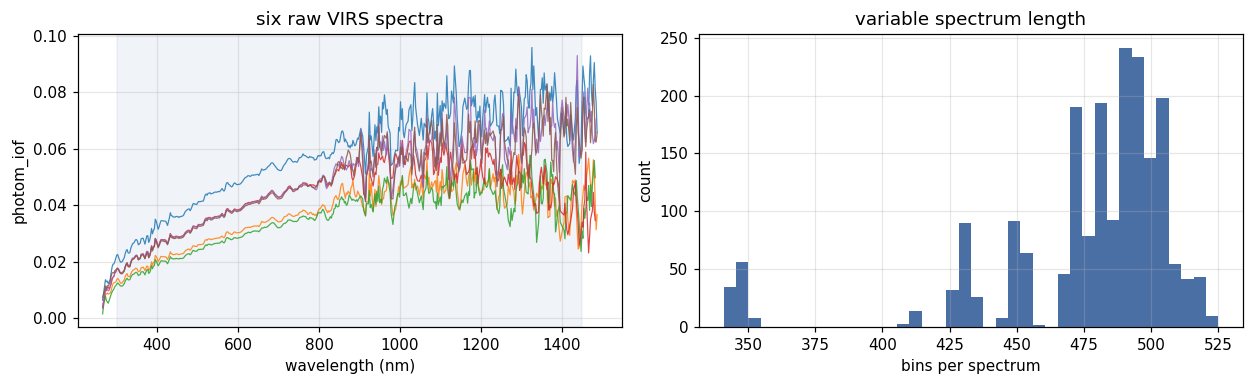

In [6]:
sample = pd.read_csv(SPECTRA, nrows=2000)
waves = sample.waves.map(ast.literal_eval)
iof_s = sample.photom_iof.map(ast.literal_eval)
nbin = waves.map(len)
lo, hi = waves.map(min), waves.map(max)

check("spectres-002.dat has the expected columns",
      {"ref_id", "waves", "photom_iof", "obs_id"} <= set(sample.columns),
      ", ".join(sample.columns))
check("spectra have a variable number of bins", nbin.nunique() > 1,
      f"{nbin.min()} to {nbin.max()} bins, median {int(nbin.median())}")
check("coverage spans the 300-1450 nm target grid",
      float(lo.median()) < 310 and float(hi.median()) > 1440,
      f"median coverage {lo.median():.0f} to {hi.median():.0f} nm")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for i in range(6):
    ax[0].plot(waves.iloc[i], iof_s.iloc[i], lw=0.8, alpha=0.85)
ax[0].axvspan(300, 1450, color="#4a6fa5", alpha=0.08)
ax[0].set(xlabel="wavelength (nm)", ylabel="photom_iof",
          title="six raw VIRS spectra")
ax[1].hist(nbin, bins=40, color="#4a6fa5")
ax[1].set(xlabel="bins per spectrum", ylabel="count",
          title="variable spectrum length")
fig.tight_layout()

## 6. The footprints, and why the model has a floor

Each MASCS spectrum comes from a ground footprint of roughly 1 to 5 km (median length
3.7 km, a few reaching tens of km), while an MDIS
pixel is 665 m. Several footprints therefore average nearly the same 8-band input while
keeping spectrum-specific variance in the target: the mapping is one-to-many, and the
achievable MSE is bounded below by a **k-NN floor**, not by zero. The figure makes the
scale mismatch concrete.

Use `shapes.dat::foot_geom` (a WKT polygon of about ten vertices) rather than the four
corners in `geometry.dat`.

Only the head of the file is read, and it happens to hold high-latitude footprints, so
the grid cells in the left panel look foreshortened in longitude: the mosaic is
equirectangular, a cell is always 1/64 deg on each side, which is 665 m in latitude and
less than that on the ground in longitude away from the equator.

[PASS]  shapes.dat carries WKT footprint polygons    ref_id, foot_geom, point_geom
[PASS]  polygons are finer than the four corners of geometry.dat    median 11 vertices
[PASS]  footprints are larger than an MDIS pixel (665 m)    median length 5,146 m, width 3,474 m


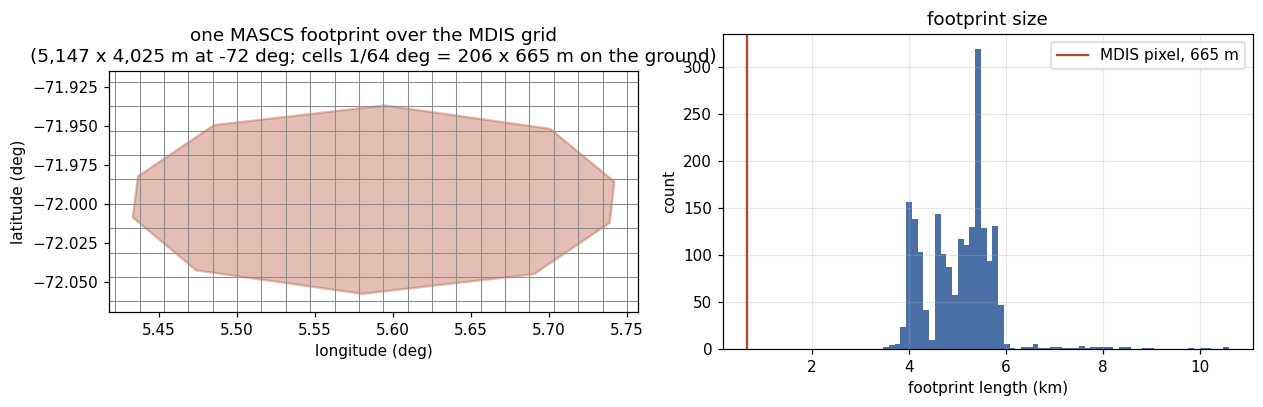

In [7]:
from shapely import wkt  # noqa: E402

shp = pd.read_csv(SHAPES, nrows=2000)
geo = pd.read_csv(GEOMETRY, nrows=2000, usecols=["ref_id", "length", "width", "surface"])
foot = shp.merge(geo, on="ref_id")
foot["poly"] = foot.foot_geom.map(wkt.loads)


def n_vertices(g):
    # A few footprints straddle the 0/360 seam and come back as MultiPolygon.
    return sum(len(part.exterior.coords) for part in getattr(g, "geoms", [g]))


nvert = foot.poly.map(n_vertices)

check("shapes.dat carries WKT footprint polygons",
      {"foot_geom", "point_geom"} <= set(shp.columns), ", ".join(shp.columns))
check("polygons are finer than the four corners of geometry.dat",
      int(nvert.median()) > 5, f"median {int(nvert.median())} vertices")
check("footprints are larger than an MDIS pixel (665 m)",
      float(foot["length"].median()) > 665.0,
      f"median length {foot['length'].median():,.0f} m, "
      f"width {foot['width'].median():,.0f} m")

simple = foot[foot.poly.map(lambda g: g.geom_type == "Polygon")].reset_index(drop=True)
i = int(np.argmin(np.abs(simple["length"].to_numpy() - simple["length"].median())))
poly = simple.poly.iloc[i]
x, y = np.array(poly.exterior.xy[0]), np.array(poly.exterior.xy[1])
x = np.where(x > 180, x - 360, x)
PX = 1 / 64                                   # MDIS pixel, in degrees

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].fill(x, y, color="#b3452a", alpha=0.35, ec="#b3452a", lw=1.5)
for g in np.arange(np.floor(x.min() / PX) * PX, x.max() + PX, PX):
    ax[0].axvline(g, color="0.55", lw=0.7)
for g in np.arange(np.floor(y.min() / PX) * PX, y.max() + PX, PX):
    ax[0].axhline(g, color="0.55", lw=0.7)
lat0 = float(np.mean(y))
px_lon_m = 665.24315270546 * np.cos(np.radians(lat0))
ax[0].set(xlabel="longitude (deg)", ylabel="latitude (deg)", aspect="equal",
          title=f"one MASCS footprint over the MDIS grid\n"
                f"({simple['length'].iloc[i]:,.0f} x {simple['width'].iloc[i]:,.0f} m at "
                f"{lat0:.0f} deg; cells 1/64 deg = {px_lon_m:.0f} x 665 m on the ground)")
ax[0].grid(False)
ax[1].hist(foot["length"] / 1000, bins=60, color="#4a6fa5")
ax[1].axvline(0.665, color="#b3452a", lw=1.5, label="MDIS pixel, 665 m")
ax[1].set(xlabel="footprint length (km)", ylabel="count", title="footprint size")
ax[1].legend()
fig.tight_layout()

## 7. The derived tables, if steps 1-2 have already run

`pairs.parquet` and `splits.parquet` come out of step 1, `virs_lsf_target.parquet` out
of step 2. The important check is the last one: the split is grouped on `obs_id`, so
**no observation may appear in two splits**. A random split would leak spatially
neighbouring spectra between train and test and false every metric.

pairs    153,214 rows, 5,624 observations
split
fold0    26260
fold1    28221
fold2    26470
fold3    30682
fold4    26534
test     15047
[PASS]  pairs.parquet holds the reference 153 214 rows    153,214 rows
[PASS]  every pair has a split    0 orphans
[PASS]  no observation is split across folds (no spatial leakage)    max splits per obs_id = 1


[PASS]  the training target is on the 231-band 5 nm grid    231 bands on 153,214 sampled rows
NaN fraction in the target: 0.11% (genuine gaps, left unbridged on purpose; the loss is NaN-tolerant)


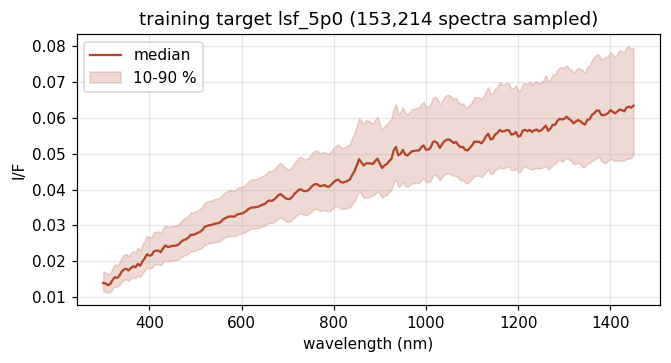

In [8]:
import pyarrow.parquet as pq  # noqa: E402

PAIRS, SPLITS, LSF = (PROC / "pairs.parquet", PROC / "splits.parquet",
                      PROC / "virs_lsf_target.parquet")

if not (PAIRS.exists() and SPLITS.exists()):
    print("skipped: run step 1 (scripts/01_build_pairs.py) first")
else:
    pairs = pd.read_parquet(PAIRS, columns=["ref_id", "obs_id", "mdis_image_count"])
    splits = pd.read_parquet(SPLITS)
    merged = pairs.merge(splits, on="ref_id", how="left")
    spans = merged.groupby("obs_id")["split"].nunique()

    print(f"pairs   {len(pairs):>8,} rows, {pairs.obs_id.nunique():,} observations")
    print(splits["split"].value_counts().sort_index().to_string())

    check("pairs.parquet holds the reference 153 214 rows",
          abs(len(pairs) - 153_214) < 5_000, f"{len(pairs):,} rows")
    check("every pair has a split", int(merged["split"].isna().sum()) == 0,
          f"{int(merged['split'].isna().sum())} orphans")
    check("no observation is split across folds (no spatial leakage)",
          int(spans.max()) == 1, f"max splits per obs_id = {int(spans.max())}")

    if LSF.exists():
        head = pq.ParquetFile(LSF).read_row_group(0, columns=["ref_id", "lsf_5p0"]).to_pandas()
        Y = np.vstack(head.lsf_5p0.values).astype(np.float32)
        check("the training target is on the 231-band 5 nm grid", Y.shape[1] == 231,
              f"{Y.shape[1]} bands on {len(Y):,} sampled rows")
        print(f"NaN fraction in the target: {np.isnan(Y).mean():.2%} "
              f"(genuine gaps, left unbridged on purpose; the loss is NaN-tolerant)")

        fig, ax = plt.subplots(figsize=(6.2, 3.4))
        grid = np.arange(300.0, 1450.0 + 5.0, 5.0)
        ax.plot(grid, np.nanmedian(Y, axis=0), color="#b3452a", label="median")
        ax.fill_between(grid, np.nanpercentile(Y, 10, axis=0),
                        np.nanpercentile(Y, 90, axis=0), color="#b3452a", alpha=0.2,
                        label="10-90 %")
        ax.set(xlabel="wavelength (nm)", ylabel="I/F",
               title=f"training target lsf_5p0 ({len(Y):,} spectra sampled)")
        ax.legend()
        fig.tight_layout()
    else:
        print("virs_lsf_target.parquet absent: run step 2 to build the training target")

## Summary

In [9]:
summary = pd.DataFrame(CHECKS)
failed = int((summary["result"] == "FAIL").sum())
print(f"{len(summary)} checks, {failed} failed")
print("The data matches the reference run." if failed == 0 else
      "Read the FAIL lines before running the pipeline: the numbers downstream will differ.")
summary

26 checks, 0 failed
The data matches the reference run.


,check,result,detail
0,every required input file is present,PASS,6/6 files found
1,MDIS width = 23040,PASS,read 23040
2,MDIS height = 11521,PASS,read 11521
3,MDIS count = 17,PASS,read 17
4,MDIS dtype = float32,PASS,read float32
5,pixel size 665.24315270546 m (1/64 deg at the ...,PASS,read 665.243152705 m
6,CRS is equirectangular on a Mercury sphere of ...,PASS,"PROJCS[""Equirectangular Mercury"""
7,nodata is the large negative nodata value,PASS,-3.402823e+38
8,bands 1-8 rise with wavelength (Mercury's red ...,PASS,median I/F 0.042 -> 0.085
9,"band 9 is integer-valued (a count, not an angle)",PASS,"81% of pixels exactly integer, 189,853 distinc..."
